# Evaluation Metrics

CTR prediction is a binary classification problem where the model predicts the probability that an advertisement impression will result in a click.

The following metrics are used to evaluate the model:

- Log Loss
- ROC-AUC
- PR-AUC
- Precision
- Recall
- Calibration
- Lift

Accuracy is not the primary metric because CTR data is imbalanced. Most advertisements are not clicked, so a model can achieve high accuracy by predicting no click for most impressions.

Log Loss is the primary metric because the objective is to predict accurate click probabilities.

In [5]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    log_loss,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.inspection import permutation_importance

In [7]:
hist_model = joblib.load(
    "..data/processed/hist_gradient_model.pkl"
)

print("Selected model loaded successfully")

Processed data folder: /Users/kamakshiilapavuluri/avazu_ctr_prediction/data/processed


# Load Validation Data
The chronological validation dataset is loaded for final model evaluation.

In [10]:
X_validation = pd.read_parquet(
    "data/processed/X_validation.parquet"
)

y_validation = pd.read_parquet(
    "data/processed/y_validation.parquet"
)["click"]

In [11]:
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

X_validation: (6064345, 26)
y_validation: (6064345,)


In [12]:
validation_sample_size = 1_000_000

X_validation_sample = X_validation.iloc[
    :validation_sample_size
].copy()

y_validation_sample = y_validation.iloc[
    :validation_sample_size
].copy()

In [13]:
print("Validation sample:", X_validation_sample.shape)

Validation sample: (1000000, 26)


## Predict Click Probabilities
The model predicts the probability that each advertisement impression will result in a click.


In [14]:
y_probability = hist_model.predict_proba(
    X_validation_sample
)[:, 1]

In [15]:
y_probability[:10]

array([0.14562187, 0.11165592, 0.22638195, 0.19789662, 0.08131247,
       0.0960983 , 0.08219807, 0.29689388, 0.08219807, 0.20797839])

## Log Loss

Log Loss measures the accuracy of predicted click probabilities.

Lower Log Loss indicates better probability predictions.

Log Loss is the primary evaluation metric for this CTR prediction project.

In [16]:
model_log_loss = log_loss(
    y_validation_sample,
    y_probability
)

print("Log Loss:", model_log_loss)

Log Loss: 0.3743042917456869


## ROC-AUC

ROC-AUC measures the model's ability to separate clicked and non-clicked advertisement impressions.

A higher ROC-AUC indicates better ranking performance.

In [17]:
model_roc_auc = roc_auc_score(
    y_validation_sample,
    y_probability
)

print("ROC-AUC:", model_roc_auc)

ROC-AUC: 0.6587269543200731


## PR-AUC

PR-AUC focuses on the positive click class.

It is useful for CTR prediction because clicks are less frequent than non-clicks.

In [18]:
model_pr_auc = average_precision_score(
    y_validation_sample,
    y_probability
)

print("PR-AUC:", model_pr_auc)

PR-AUC: 0.26005595364889317


## Threshold Selection

Different probability thresholds are evaluated to understand the tradeoff between Precision and Recall.

The F1 score is calculated at each threshold to provide a simple balance between Precision and Recall.

The threshold with the highest F1 score is identified as a candidate classification threshold.

# Calculate Precision and Recall
Initial Threshold 0.5

In [19]:
y_prediction = (
    y_probability >= 0.5
).astype(int)

In [20]:
model_precision = precision_score(
    y_validation_sample,
    y_prediction,
    zero_division=0
)

model_recall = recall_score(
    y_validation_sample,
    y_prediction,
    zero_division=0
)

print("Precision:", model_precision)
print("Recall:", model_recall)

Precision: 0.46769373796400826
Recall: 0.05252129039955853


# Threshold Selection

In [24]:

threshold_results = []

for threshold in np.arange(0.05, 0.55, 0.05):

    y_pred_threshold = (
        y_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation_sample,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_validation_sample,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_validation_sample,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    })

In [25]:
threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1_Score
0,0.05,0.139831,0.967829,0.244357
1,0.10,0.181450,0.690331,0.287368
2,0.15,0.228258,0.460566,0.305239
3,0.20,0.262728,0.353667,0.301489
4,0.25,0.303557,0.274956,0.288550
5,0.30,0.363033,0.181852,0.242320
6,0.35,0.435246,0.105110,0.169328
7,0.40,0.470406,0.074796,0.129070
8,0.45,0.471609,0.067697,0.118398
9,0.50,0.467694,0.052521,0.094437


In [21]:
# Create your evaluation table
evaluation_results = pd.DataFrame({
    "Metric": [
        "Log Loss",
        "ROC-AUC",
        "PR-AUC",
        "Precision",
        "Recall"
    ],
    "Value": [
        model_log_loss,
        model_roc_auc,
        model_pr_auc,
        model_precision,
        model_recall
    ]
})

evaluation_results

,Metric,Value
0,Log Loss,0.374304
1,ROC-AUC,0.658727
2,PR-AUC,0.260056
3,Precision,0.467694
4,Recall,0.052521


In [26]:
# F1 threshold
best_threshold_row = threshold_df.loc[
    threshold_df["F1_Score"].idxmax()
]

best_threshold_row

Threshold    0.150000
Precision    0.228258
Recall       0.460566
F1_Score     0.305239
Name: 2, dtype: float64

In [27]:
best_threshold = best_threshold_row[
    "Threshold"
]

print(
    "Best threshold based on F1:",
    best_threshold
)

Best threshold based on F1: 0.15000000000000002


### Threshold Selection Result

The default threshold of 0.5 produced higher Precision but very low Recall, identifying only a small percentage of actual clicks.

Different probability thresholds were evaluated to understand the tradeoff between Precision and Recall.

A threshold of 0.15 produced the highest F1 score.

At this threshold:

- Precision = 0.2283
- Recall = 0.4606
- F1 Score = 0.3052

Therefore, 0.15 was identified as a candidate classification threshold because it provided the best balance between Precision and Recall among the evaluated thresholds.

The final threshold may depend on the business objective. For example, a higher threshold may be preferred when Precision is more important, while a lower threshold may be preferred when identifying more potential clicks is more important.

## Calibration

Calibration checks whether the predicted click probabilities are close to the actual click rates.

For example, if the model predicts a click probability of 0.20 for a group of impressions, approximately 20% of those impressions should result in clicks for a well-calibrated model.

Calibration is important in CTR prediction because the model predicts click probabilities.

In [28]:
actual_rate, predicted_probability = calibration_curve(
    y_validation_sample,
    y_probability,
    n_bins=10
)

In [29]:
print("Actual click rate:")
print(actual_rate)

print("Predicted probability:")
print(predicted_probability)

Actual click rate:
[0.08477774 0.1369455  0.20328037 0.31310113 0.47692799 0.4479625
 0.6940874  0.81481481]
Predicted probability:
[0.07027919 0.13651772 0.24843489 0.33236651 0.46054917 0.54752779
 0.61874129 0.73110428]


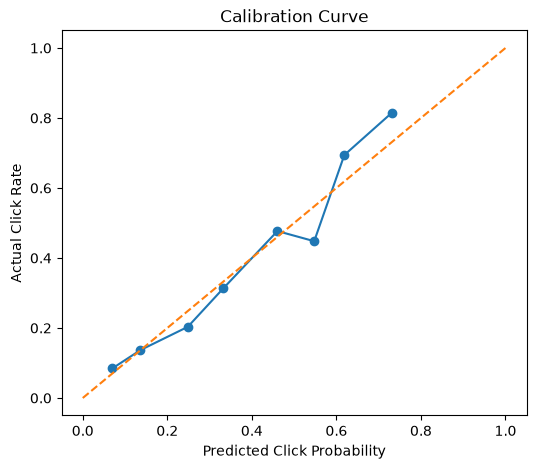

In [30]:
plt.figure(figsize=(6, 5))

plt.plot(
    predicted_probability,
    actual_rate,
    marker="o"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Predicted Click Probability")
plt.ylabel("Actual Click Rate")
plt.title("Calibration Curve")

plt.show()

### Calibration Result

The calibration curve compares the predicted click probability with the actual click rate.

The model is reasonably calibrated in the lower and middle probability ranges because the calibration curve remains relatively close to the perfect calibration line.

Some deviations are observed at higher predicted probabilities. In some probability ranges, the model slightly overestimates or underestimates the actual click rate.

Overall, the predicted probabilities show a reasonable relationship with the observed click rates.

## Lift Analysis

Lift measures whether the model identifies impressions with a higher click rate than the overall average click rate.

Predictions are ranked from highest to lowest predicted click probability.

The validation data is divided into ten groups. The actual click rate of each group is compared with the overall click rate.

A lift greater than 1 indicates that the model identifies users or impressions with a higher click probability than random selection.

In [43]:
# Taking copy because,going to add : actual click and predicted probability

lift_data = X_validation_sample.copy()

In [44]:
lift_data["actual_click"] = y_validation_sample.values

In [45]:
lift_data["predicted_probability"] = y_probability

In [46]:
# Sort highest probability first

lift_data = lift_data.sort_values(
    by="predicted_probability",
    ascending=False
)

In [47]:
# Divide into 10 groups

lift_data["group"] = pd.qcut(
    range(len(lift_data)),
    q=10,
    labels=False
)

In [48]:
# actual CTR by group

lift_table = lift_data.groupby(
    "group"
)["actual_click"].mean().reset_index()

In [49]:
# overall CTR

overall_ctr = lift_data["actual_click"].mean()


In [51]:
# Calculate lift

lift_table["lift"] = (
    lift_table["actual_click"] / overall_ctr
)

lift_table

,group,actual_click,lift
0,0,0.32244,2.404510
1,1,0.18272,1.362586
2,2,0.14843,1.106877
3,3,0.13701,1.021715
4,4,0.12418,0.926039
5,5,0.11202,0.835359
6,6,0.10686,0.796880
7,7,0.06934,0.517085
8,8,0.07774,0.579725
9,9,0.06024,0.449224


Lift measures how much better the model’s selected high-probability group performs compared with the overall average. The top 10% predicted group achieved a lift of 2.4, meaning its actual click rate was 2.4 times the overall click rate.

# Final Model Evaluation Summary

The CTR model was evaluated using Log Loss, ROC-AUC, PR-AUC, Precision, Recall, Calibration, and Lift.

Accuracy was not used as the main metric because CTR data is imbalanced. Most impressions do not result in clicks. A model could predict "no click" for most impressions and still achieve high accuracy while failing to identify actual clicks.

Log Loss was used to evaluate the quality of predicted click probabilities.

ROC-AUC was used to evaluate how well the model ranks clicked impressions above non-clicked impressions.

PR-AUC was used to evaluate the positive click class because clicks are less frequent than non-clicks.

Precision and Recall were used to understand the tradeoff between correct click predictions and identifying actual clicks.

The default threshold of 0.5 produced very low Recall. Different thresholds were evaluated, and 0.15 achieved the highest F1 score among the tested thresholds.

Calibration was used to compare predicted click probabilities with actual click rates.

Lift was used to measure whether the model identifies high-value impressions. The top 10% predicted group achieved a lift of approximately 2.4, meaning its actual click rate was approximately 2.4 times the overall click rate.

I would optimize Log Loss first because CTR prediction is mainly a probability prediction problem. The model needs to predict accurate click probabilities.

The HistGradientBoosting model improved Log Loss and ROC-AUC compared with the Logistic Regression baseline.

Based on the improvement over the baseline, threshold analysis, calibration, and lift results, HistGradientBoosting was selected as the preferred model for further evaluation.